## 1. Setup

In [ ]:
import os, re, math
from collections import Counter

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

import nltk
try:
    nltk.corpus.stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

%matplotlib inline

In [ ]:
# Stop words: nltk's English list, plus punctuation tokens that survive splitting.
# 'illustration' is Gutenberg's caption markup, not the author's vocabulary.
STOP_WORDS = set(nltk.corpus.stopwords.words('english')) | {
    'ut', "'re", '.', ',', '--', "'s", '?', ')', '(', ':', "'", '"', '-', '}', '{',
    '&', '|', u'—', '', 'illustration'}

BOOKS = {
    'Great Expectations':        dict(id=1400, author='Charles Dickens',    short='GreatEx'),
    'David Copperfield':         dict(id=766,  author='Charles Dickens',    short='Copperfield'),
    'Sherlock Holmes':           dict(id=1661, author='Arthur Conan Doyle', short='Holmes'),
    'Hound of the Baskervilles': dict(id=2852, author='Arthur Conan Doyle', short='Hound'),
}
AUTHORS = ['Charles Dickens', 'Arthur Conan Doyle']

DICKENS, DOYLE = '#2a78d6', '#eb6834'
COLOR = {'Charles Dickens': DICKENS, 'Arthur Conan Doyle': DOYLE}
SURFACE, INK, INK_SOFT, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e3e2df'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK_SOFT, 'axes.edgecolor': GRID,
    'xtick.color': INK_SOFT, 'ytick.color': INK_SOFT, 'font.size': 11,
    'axes.titlesize': 12, 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def tidy(ax):
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color=GRID, lw=0.8)
    ax.yaxis.grid(False)
    ax.tick_params(length=0)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)

## 2. Download and cleanStrip the Gutenberg licence header/footer (identical in all four files, so leaving it inwould make every author look more alike), lowercase, remove punctuation and numbers, thendrop stop words. Downloads are cached so re-running does not re-fetch.

In [ ]:
CACHE = 'gutenberg_cache'
os.makedirs(CACHE, exist_ok=True)

def fetch(title):
    path = os.path.join(CACHE, f"{BOOKS[title]['id']}.txt")
    if not os.path.exists(path):
        url = f"https://www.gutenberg.org/ebooks/{BOOKS[title]['id']}.txt.utf-8"
        r = requests.get(url, timeout=90)
        r.raise_for_status()
        with open(path, 'w', encoding='utf-8') as f:
            f.write(r.text)
    with open(path, encoding='utf-8', errors='replace') as f:
        return f.read()

def strip_boilerplate(t):
    s = t.find('*** START OF')
    if s != -1:
        t = t[t.find('\n', s) + 1:]
    e = t.find('*** END OF')
    return t[:e] if e != -1 else t

def clean_word(w):
    w = re.sub(r'[,"\.\'&\|:@>*;/=\?!\(\)\[\]_“”‘’]', '', w)
    w = re.sub(r'^-+|-+$', '', w)
    return re.sub(r'^[0-9\.]*$', '', w)

def get_words(title):
    """Raw text -> list of regular (non-stop) words."""
    text = strip_boilerplate(fetch(title)).lower()
    words = (clean_word(w) for w in re.split(r'\s+', text))
    return [w for w in words if w and w not in STOP_WORDS]

In [ ]:
WORDS  = {t: get_words(t) for t in BOOKS}
COUNTS = {t: Counter(WORDS[t]) for t in BOOKS}
TOTAL  = {t: len(WORDS[t]) for t in BOOKS}      # N = binomial trials

pd.DataFrame([{'Book': t, 'Author': BOOKS[t]['author'],
               'Regular words': TOTAL[t], 'Unique words': len(COUNTS[t])} for t in BOOKS])

,Book,Author,Regular words,Unique words
0,Great Expectations,Charles Dickens,83376,12219
1,David Copperfield,Charles Dickens,163330,16801
2,Sherlock Holmes,Arthur Conan Doyle,46719,8248
3,Hound of the Baskervilles,Arthur Conan Doyle,26663,5696


The books differ a lot in length — *David Copperfield* has ~6× the regular words of *Hound*— so every comparison below uses a **rate per 10,000 words**, not raw counts.

In [ ]:
def top_words(title, k=15):
    return [(w, c / TOTAL[title] * 10000) for w, c in COUNTS[title].most_common(k)]

def plot_top(ax, title, color, xmax, k=15):
    data = top_words(title, k)[::-1]                # barh draws bottom-up
    vals = [r for _, r in data]
    ax.barh(range(len(data)), vals, color=color, height=0.68)
    ax.set_yticks(range(len(data)), [w for w, _ in data])
    ax.set_title(title, color=INK, pad=10, loc='left', fontweight='bold')
    ax.set_xlabel('per 10,000 regular words')
    ax.set_xlim(0, xmax)
    for i, v in enumerate(vals):
        ax.text(v + xmax * 0.015, i, f'{v:.0f}', va='center', fontsize=9, color=INK_SOFT)
    tidy(ax)

def compare(b1, b2, c1, c2, suptitle):
    """Two books side by side on a shared x-scale so bar lengths are comparable."""
    xmax = max(r for b in (b1, b2) for _, r in top_words(b)) * 1.18
    fig, axes = plt.subplots(1, 2, figsize=(11, 6))
    fig.suptitle(suptitle, fontsize=15, fontweight='bold', x=0.02, ha='left')
    plot_top(axes[0], b1, c1, xmax)
    plot_top(axes[1], b2, c2, xmax)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

## 3. Question 1 — two works by the same author

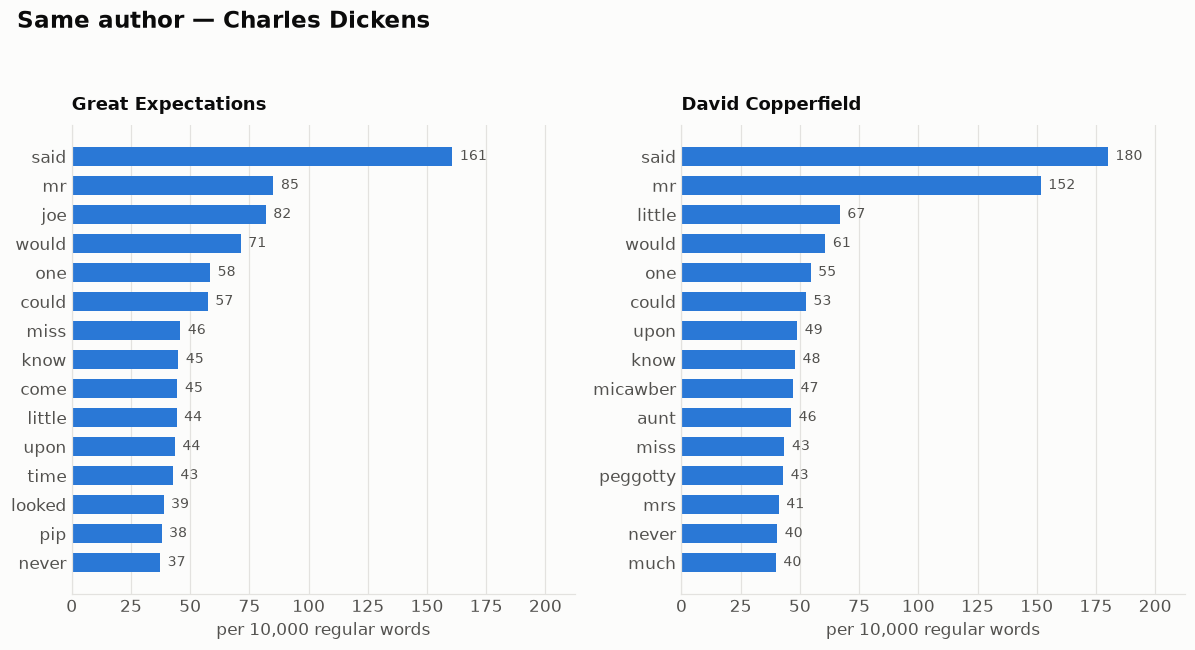

In [ ]:
compare('Great Expectations', 'David Copperfield', DICKENS, DICKENS,
        'Same author — Charles Dickens')

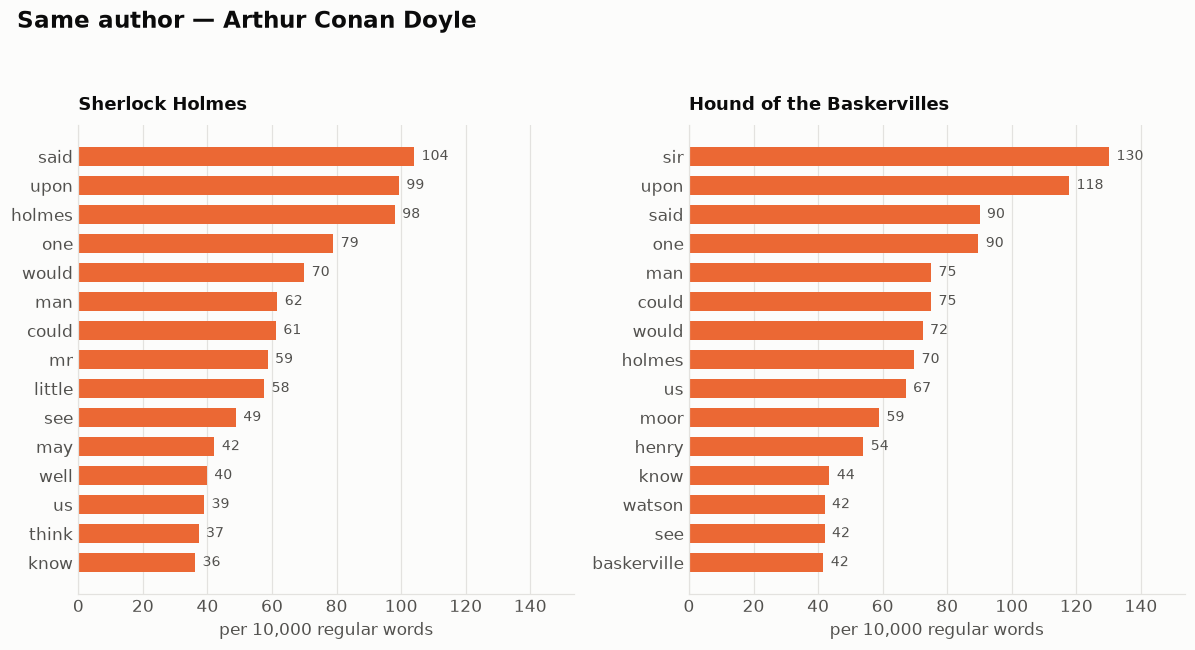

In [ ]:
compare('Sherlock Holmes', 'Hound of the Baskervilles', DOYLE, DOYLE,
        'Same author — Arthur Conan Doyle')

**Result.** Ignoring character names, the two Dickens novels share 10 of their top 15 words(*said, mr, would, one, could, miss, know, little, upon, never*) at similar rates — *said*leads both, at 161 and 180 per 10k. Doyle's two novels likewise share *said, upon, one,would, man, could, know, see*. **An author's frequent vocabulary is largely stable acrosstheir own books.**

## 4. Question 2 — two different authors

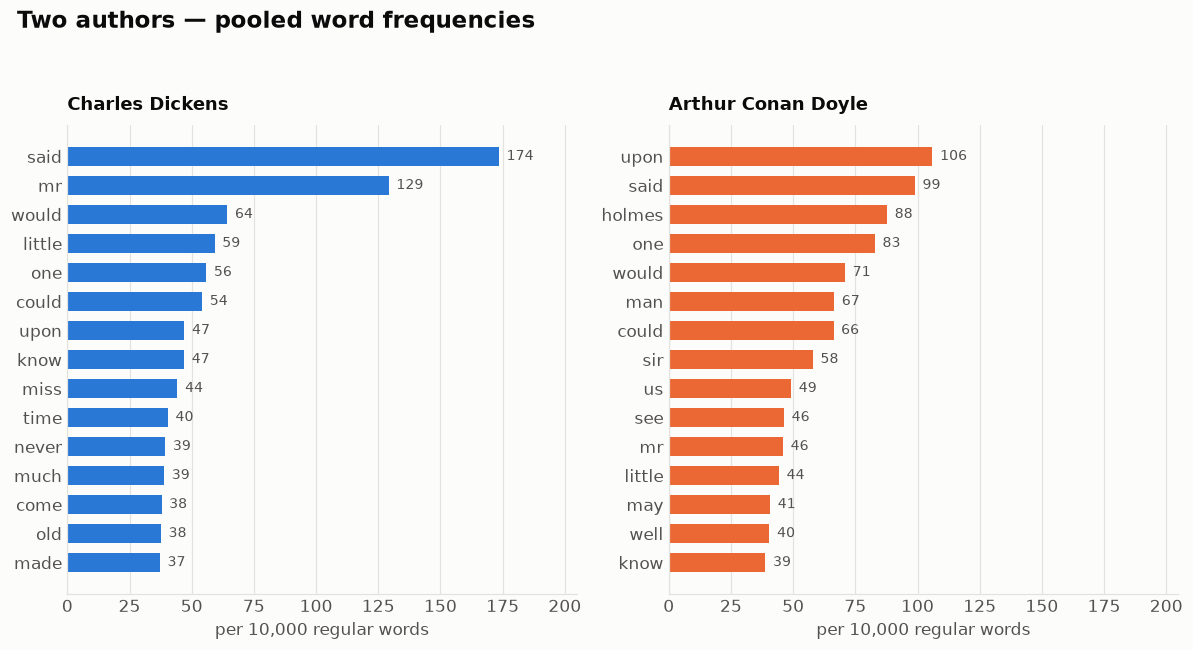

In [ ]:
BY_AUTHOR = {a: sum((COUNTS[t] for t in BOOKS if BOOKS[t]['author'] == a), Counter())
             for a in AUTHORS}
N_AUTHOR = {a: sum(BY_AUTHOR[a].values()) for a in AUTHORS}

def top_author(a, k=15):
    return [(w, c / N_AUTHOR[a] * 10000) for w, c in BY_AUTHOR[a].most_common(k)]

xmax = max(r for a in AUTHORS for _, r in top_author(a)) * 1.18
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
fig.suptitle('Two authors — pooled word frequencies', fontsize=15, fontweight='bold',
             x=0.02, ha='left')
for ax, a in zip(axes, AUTHORS):
    data = top_author(a)[::-1]
    vals = [r for _, r in data]
    ax.barh(range(len(data)), vals, color=COLOR[a], height=0.68)
    ax.set_yticks(range(len(data)), [w for w, _ in data])
    ax.set_title(a, color=INK, pad=10, loc='left', fontweight='bold')
    ax.set_xlabel('per 10,000 regular words')
    ax.set_xlim(0, xmax)
    for i, v in enumerate(vals):
        ax.text(v + xmax * 0.015, i, f'{v:.0f}', va='center', fontsize=9, color=INK_SOFT)
    tidy(ax)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

**Result.** The two lists overlap heavily (*said, one, would, could, know, little, mr*) —expected, since both are Victorian British novelists writing first-person prose. Thedifference is in the **weights**: Dickens uses *said* at 174 per 10k against Doyle's 99,while Doyle uses *upon* at 106 against Dickens's 47 and *man* at 67 against Dickens's 27.

## 5. Question 3 — words preferred by one authorFor each word, compare its rate in Dickens against Doyle using the log₂ ratio$$\text{score}(w) = \log_2 \frac{r_D(w) + 0.5}{r_C(w) + 0.5}$$(+0.5 smoothing so a word absent from one author gives a finite score). Words need 25+combined occurrences, and character/place names are excluded — *Pip* and *Holmes* separatethe books perfectly but describe the plot, not the writer.

In [ ]:
NAMES = set('''
pip joe estella havisham biddy herbert wemmick jaggers magwitch pumblechook orlick pocket
compeyson provis gargery trabb startop drummle camilla sarah georgiana clara wopsle mike
david davy copperfield murdstone peggotty micawber betsey trotwood steerforth uriah heep
agnes wickfield dora spenlow traddles barkis emly emily ham creakle dick mell littimer
gummidge chillip jorkins crupp markleham annie sophy janet omer maldon sharp tiffey jip
mills trot dartle rosa
holmes watson sherlock lestrade adler irene moriarty mycroft hudson baskerville henry
stapleton mortimer barrymore selden frankland laura lyons charles grimpen devonshire
dartmoor simon rucastle mccarthy openshaw hosmer windibank roylott stoner coram
london england french paris norfolk yarmouth canterbury
'''.split())

rows = []
for w in set(BY_AUTHOR['Charles Dickens']) | set(BY_AUTHOR['Arthur Conan Doyle']):
    a, b = BY_AUTHOR['Charles Dickens'][w], BY_AUTHOR['Arthur Conan Doyle'][w]
    if a + b < 25 or w in NAMES or w.rstrip('s') in NAMES:   # rstrip catches possessives
        continue
    ra = a / N_AUTHOR['Charles Dickens'] * 10000
    rb = b / N_AUTHOR['Arthur Conan Doyle'] * 10000
    rows.append({'word': w, 'Dickens n': a, 'Doyle n': b, 'Dickens /10k': ra,
                 'Doyle /10k': rb, 'log2 ratio': math.log2((ra + 0.5) / (rb + 0.5))})

df = pd.DataFrame(rows).sort_values('log2 ratio', ascending=False)
marked = pd.concat([df.head(14), df.tail(14)])
marked.round(2).reset_index(drop=True)

,word,Dickens n,Doyle n,Dickens /10k,Doyle /10k,log2 ratio
0,aunt,756,2,30.64,0.27,5.33
1,replied,273,3,11.07,0.41,3.67
2,aint,141,0,5.72,0.00,3.64
3,masr,114,0,4.62,0.00,3.36
4,coach,112,0,4.54,0.00,3.33
5,em,111,0,4.50,0.00,3.32
6,maam,106,0,4.30,0.00,3.26
7,parlour,92,0,3.73,0.00,3.08
8,shes,80,0,3.24,0.00,2.90
9,couldnt,140,3,5.67,0.41,2.76


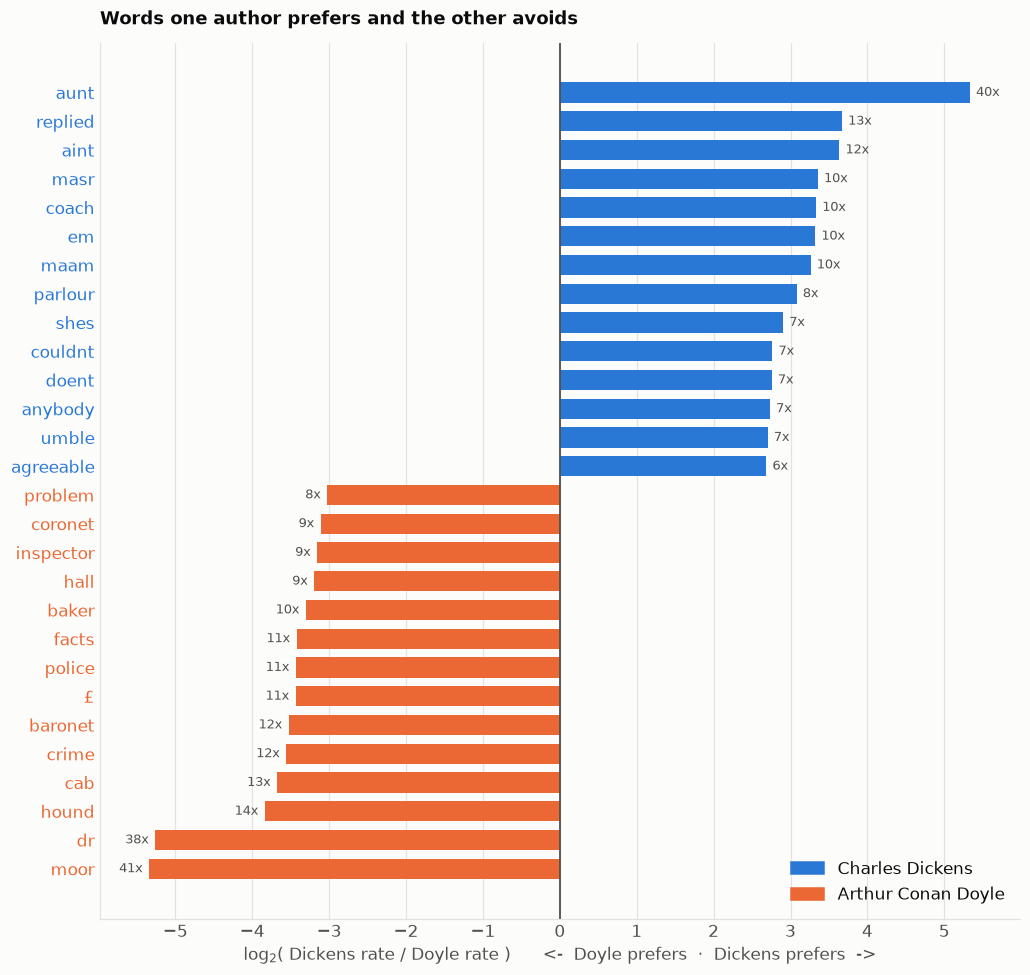

In [ ]:
d = marked.sort_values('log2 ratio')
colors = [DICKENS if v > 0 else DOYLE for v in d['log2 ratio']]

fig, ax = plt.subplots(figsize=(9.5, 9))
ax.barh(range(len(d)), d['log2 ratio'], color=colors, height=0.7)
ax.set_yticks(range(len(d)), d['word'])
for tl, v in zip(ax.get_yticklabels(), d['log2 ratio']):
    tl.set_color(DICKENS if v > 0 else DOYLE)

ax.axvline(0, color=INK_SOFT, lw=1.2)
ax.set_xlabel('log$_2$( Dickens rate / Doyle rate )'
              '      <-  Doyle prefers  ·  Dickens prefers  ->')
ax.set_title('Words one author prefers and the other avoids', loc='left',
             fontweight='bold', pad=12)
ax.xaxis.set_major_locator(MultipleLocator(1))
lim = max(abs(d['log2 ratio'])) * 1.12
ax.set_xlim(-lim, lim)
for i, v in enumerate(d['log2 ratio']):
    ax.text(v + (0.08 if v > 0 else -0.08), i, f'{2**abs(v):.0f}x', va='center',
            ha='left' if v > 0 else 'right', fontsize=8.5, color=INK_SOFT)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=DICKENS, label='Charles Dickens'),
                   plt.Rectangle((0, 0), 1, 1, color=DOYLE, label='Arthur Conan Doyle')],
          loc='lower right', frameon=False)
tidy(ax)
fig.tight_layout()
plt.show()

**Result — yes, clearly.** Dickens's side is domestic (*aunt, replied, coach, parlour,maam*) plus dialect spellings from his working-class characters (*aint, em, masr, umble*).Doyle's side is a detective's toolkit (*moor, hound, cab, crime, police, baronet, facts,£*). Ratios reach 40×, and many words appear **zero** times in the other author.One caveat worth stating: much of this reflects **subject matter** as much as personalstyle — detective stories contain crimes, bildungsromans contain aunts. Words like *replied*and the dialect spellings are the more genuinely stylistic entries.

## 6. Extra credit — statistical significanceEach of a book's $N$ regular words is a trial that either is or isn't the chosen word $w$, so$$X \sim \text{Binomial}(N, p), \qquad \hat p = \frac{N(w)}{N(\text{regular words})}$$Compare two books with a two-proportion z-test against the pooled rate $\bar p$:$$z = \frac{\hat p_1 - \hat p_2}{\sqrt{\bar p(1-\bar p)\left(\frac{1}{N_1}+\frac{1}{N_2}\right)}}$$Every word is tested **twice**: within an author (the control) and between authors.

In [ ]:
def z_test(word, b1, b2):
    x1, n1 = COUNTS[b1][word], TOTAL[b1]
    x2, n2 = COUNTS[b2][word], TOTAL[b2]
    p1, p2 = x1 / n1, x2 / n2
    pooled = (x1 + x2) / (n1 + n2)
    z = (p1 - p2) / math.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    return dict(word=word, comparison=f"{BOOKS[b1]['short']} vs {BOOKS[b2]['short']}",
                rate1=p1 * 10000, rate2=p2 * 10000, z=z,
                p_value=2 * stats.norm.sf(abs(z)))

PAIRS = [
    ('within Dickens', 'Great Expectations', 'David Copperfield'),
    ('within Doyle',   'Sherlock Holmes',    'Hound of the Baskervilles'),
    ('across authors', 'Great Expectations', 'Sherlock Holmes'),
    ('across authors', 'David Copperfield',  'Hound of the Baskervilles'),
]
TEST_WORDS = ['upon', 'said', 'little', 'man', 'would', 'know']

results = pd.DataFrame([dict(kind=k, **z_test(w, b1, b2))
                        for w in TEST_WORDS for k, b1, b2 in PAIRS])
results['significant'] = np.where(results.p_value < 0.05, 'yes', 'no')
results.round({'rate1': 1, 'rate2': 1, 'z': 2, 'p_value': 5})

,kind,word,comparison,rate1,rate2,z,p_value,significant
0,within Dickens,upon,GreatEx vs Copperfield,43.5,48.9,-1.83,0.06778,no
1,within Doyle,upon,Holmes vs Hound,99.3,117.8,-2.35,0.01893,yes
2,across authors,upon,GreatEx vs Holmes,43.5,99.3,-12.14,0.00000,yes
3,across authors,upon,Copperfield vs Hound,48.9,117.8,-13.68,0.00000,yes
4,within Dickens,said,GreatEx vs Copperfield,160.7,180.1,-3.48,0.00050,yes
5,within Doyle,said,Holmes vs Hound,104.0,90.0,1.84,0.06507,no
6,across authors,said,GreatEx vs Holmes,160.7,104.0,8.34,0.00000,yes
7,across authors,said,Copperfield vs Hound,180.1,90.0,10.63,0.00000,yes
8,within Dickens,little,GreatEx vs Copperfield,44.3,66.9,-6.92,0.00000,yes
9,within Doyle,little,Holmes vs Hound,57.6,21.0,7.18,0.00000,yes


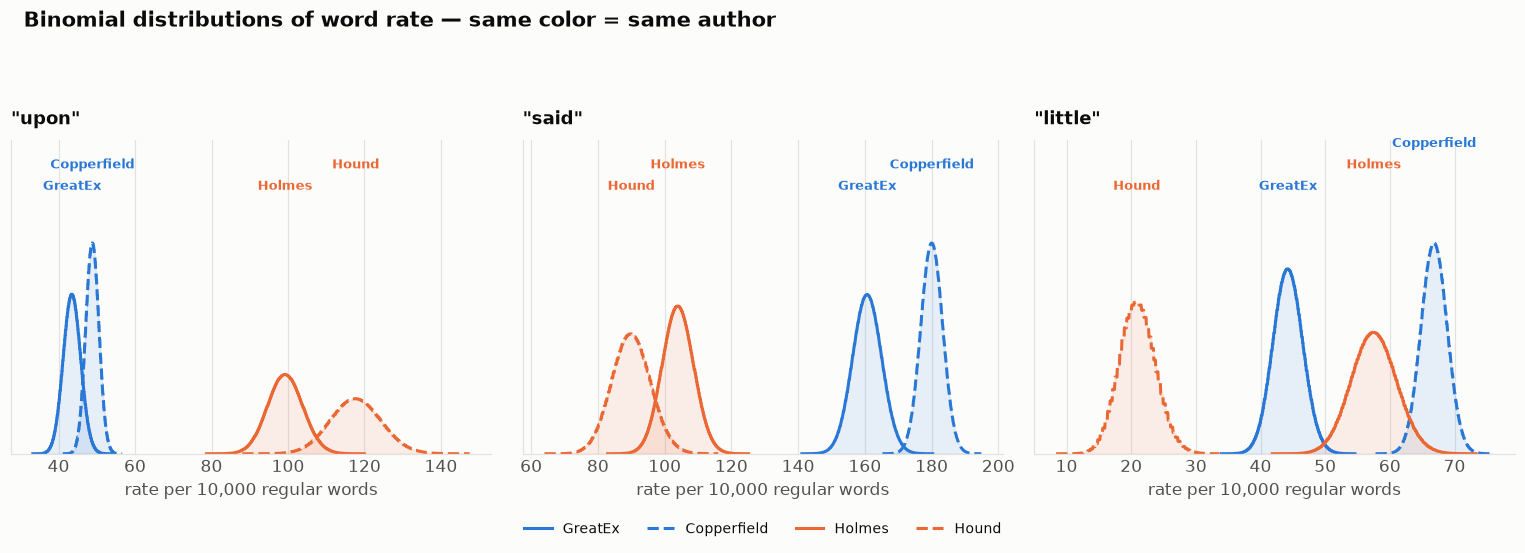

In [ ]:
def binomial_curve(title, word, npts=400):
    """Sampling distribution of the word's rate, in per-10k units so books of
    different length share one x-axis."""
    n, p = TOTAL[title], COUNTS[title][word] / TOTAL[title]
    sd = math.sqrt(n * p * (1 - p))
    ks = np.linspace(max(0, n * p - 4.5 * sd), n * p + 4.5 * sd, npts)
    return ks / n * 10000, stats.binom.pmf(np.round(ks), n, p) * n / 10000

def plot_binomials(word, ax):
    styles = {'Great Expectations': '-', 'David Copperfield': '--',
              'Sherlock Holmes': '-', 'Hound of the Baskervilles': '--'}
    peaks = []
    for t in BOOKS:
        x, y = binomial_curve(t, word)
        c = COLOR[BOOKS[t]['author']]
        ax.plot(x, y, lw=2, color=c, ls=styles[t], label=BOOKS[t]['short'])
        ax.fill_between(x, y, color=c, alpha=0.10)
        peaks.append((x[np.argmax(y)], t))

    ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.42)
    lo, hi = ax.get_xlim()
    # stack labels where two curves nearly coincide, instead of overprinting
    min_sep = (hi - lo) * 0.20
    peaks.sort()
    level, prev = 0, None
    for px, t in peaks:
        level = level + 1 if prev is not None and px - prev < min_sep else 0
        ax.annotate(BOOKS[t]['short'], xy=(px, 0.84), xycoords=('data', 'axes fraction'),
                    textcoords='offset points', xytext=(0, 14 * level), ha='center',
                    fontsize=8.5, color=COLOR[BOOKS[t]['author']], fontweight='bold')
        prev = px
    ax.set_title(f'"{word}"', loc='left', fontweight='bold', pad=10)
    ax.set_xlabel('rate per 10,000 regular words')
    ax.set_yticks([])
    tidy(ax)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.suptitle('Binomial distributions of word rate — same color = same author',
             fontsize=14, fontweight='bold', x=0.02, ha='left')
for ax, w in zip(axes, ['upon', 'said', 'little']):
    plot_binomials(w, ax)
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=[0, 0.02, 1, 0.9])
plt.show()

In [ ]:
within = results[results.kind.str.startswith('within')]
across = results[results.kind == 'across authors']
print(f"median |z|  within author : {within['z'].abs().median():.2f}")
print(f"median |z|  across authors: {across['z'].abs().median():.2f}"
      f"   ({across['z'].abs().median() / within['z'].abs().median():.1f}x larger)")

median |z|  within author : 2.24
median |z|  across authors: 7.50   (3.3x larger)


**Result — yes, and by a wide margin, but significance alone is not enough.**- **`upon` is the model marker.** Within-author it barely moves ($p = 0.07$ for Dickens,  $p = 0.02$ for Doyle); across authors $|z| = 12.1$ and $13.7$. In the plot the two blue  curves sit together, the two orange curves sit together, and the pairs never overlap.  **`said`** separates the authors just as cleanly (though it does also differ within  Dickens, $p = 0.0005$).- **`little` shows why a small p-value is not evidence of authorship.** It is significant  *within both authors* ($z = -6.9$ for Dickens, $+7.2$ for Doyle), and its four curves are  completely interleaved — *Hound* and *Copperfield* sit at opposite extremes despite having  different authors.- **`would` is worse than useless**: significant within Dickens ($z = 3.1$) but flat across  authors ($z = 0.3$ and $-2.2$). **`know`** does not move at all.With $N$ between 27,000 and 163,000 trials per book, almost any difference reaches$p < 0.05$. The evidence for authorship is the **ratio of between-author to within-authoreffect**, which here is about 3× in favour of the between-author comparison.

## Resources
## Two works by one author look alike

**Key Findings:**
- Authors maintain stable vocabulary across their own works.
- Different authors differ more in word weighting than in word choice.
- Distinctly preferred words exist between authors, often reflecting genre.
- Statistical significance tests (binomial distributions) show greater differences between authors than within, but effect size and within-author control are crucial.

**Limitations:**
- Manual filtering of names is not exhaustive.
- Word independence assumption in binomial model might lead to narrower confidence intervals than actual.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')